# **Baixar Datase**

In [ ]:
# Login No Kaggle
import kagglehub
kagglehub.login()


Kaggle credentials set.
Unable to validate Kaggle credentials at this time.


In [ ]:
# Baixar Dates

keltonmartins_colors_red_and_blue_path = kagglehub.dataset_download('keltonmartins/colors-red-and-blue')

print('Data source import complete.')


100%|██████████| 143M/143M [00:11<00:00, 12.9MB/s]

Extracting files...


Data source import complete.


# **Mover Dataset ---> Content**

In [ ]:
import shutil
import os

pasta_origem = '/root/.cache/kagglehub/datasets/keltonmartins/colors-red-and-blue/versions/4/Dataset'
pasta_destino = '/content'

try:
    # Mover a pasta
    shutil.move(pasta_origem, pasta_destino)
    print(f"Pasta movida com sucesso de '{pasta_origem}' para '{pasta_destino}'")

except FileNotFoundError:
    print("Erro: O caminho de origem não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro ao mover a pasta: {e}")

Pasta movida com sucesso de '/root/.cache/kagglehub/datasets/keltonmartins/colors-red-and-blue/versions/4/Dataset' para '/content'


# **Libs Necessárias**

In [ ]:
import os, cv2, glob as gb
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D
from keras.layers import Dense, Dropout, BatchNormalization, Rescaling, Input
from keras.layers import LeakyReLU
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.applications import MobileNetV3Small, MobileNetV2
from keras.callbacks import ModelCheckpoint
from keras.applications.mobilenet_v3 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, f1_score, precision_score
from sklearn.utils import shuffle

import pandas as pd
import warnings

# **Carregar Dateset**

In [ ]:
#  Configs Padrões
path_dataset = '/content/Dataset/'
image_size = (32, 32)
X, Y = [], []

In [ ]:
tipo = 0
pastas = sorted(os.listdir(path_dataset))
for pasta in pastas:
    arquivos = sorted(gb.glob(f"{path_dataset}{pasta}/*"))
    cont = 0
    for arquivo in arquivos:
      cont += 1
      imagem = cv2.imread(arquivo)
      imagem = cv2.resize(imagem, image_size)
      imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
      X.append(imagem)
      Y.append(tipo)

    # 0 Azul | 1 Vermelho | 2 BackGround
    tipo += 1

In [ ]:
# Conversão para Numpy Array
X = np.array(X)
Y = np.array(Y)

# **Exibir Imagens**

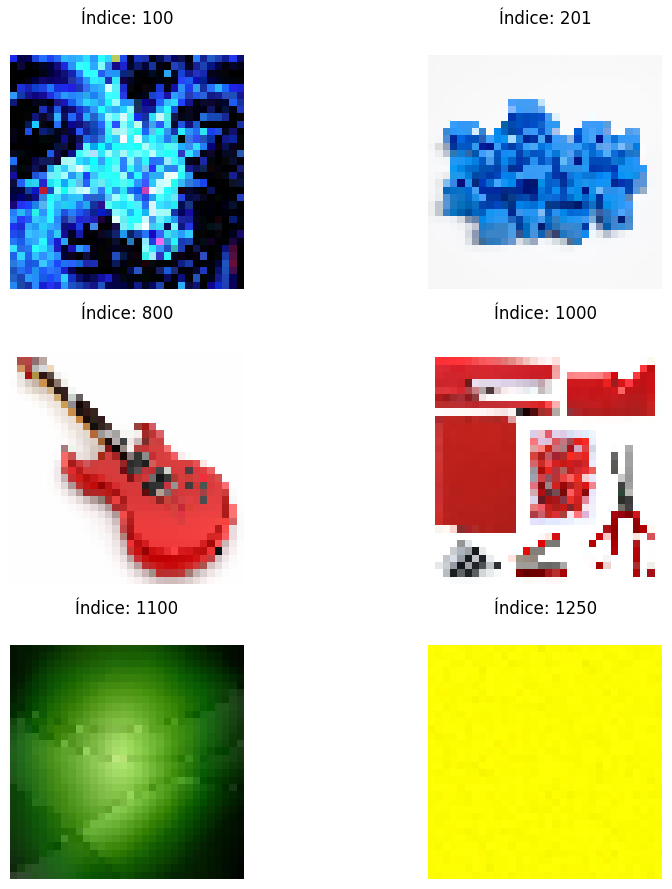

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(10, 9))

ax_list = ax.flatten()

indices = [100, 201, 800, 1000, 1100, 1250]

for i, indice in enumerate(indices):
    ax_list[i].matshow(X[indice])

    ax_list[i].set_title(f"Índice: {indice}")
    ax_list[i].axis('off')

plt.tight_layout()
plt.show()

# **Preparar Dateset**

In [ ]:
# Embaralhar as imagens
X, Y = shuffle(X, Y, random_state=42)

In [ ]:
# Dividir Treinamento, Teste e Validação
# 70% treino + 30% (val + teste)
X_treino, X_temp, y_treino, y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y
)

# 15% validação + 15% teste (metade da parte temporária)
X_val, X_teste, y_val, y_teste = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [ ]:
# Pré-processamento
X_treino = preprocess_input(X_treino)
X_teste = preprocess_input(X_teste)
X_val = preprocess_input(X_val)

# **Modelo MobileNet V3 Small**

In [ ]:
modelV3 = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
modelV3.trainable = False

modeloV3 = Sequential()
modeloV3.add(modelV3)
modeloV3.add(GlobalAveragePooling2D())
modeloV3.add(Dense(32, activation=LeakyReLU(0.01), kernel_regularizer=l2(0.001)))
modeloV3.add(Dropout(0.4))
modeloV3.add(Dense(3, activation='softmax', kernel_regularizer=l2(0.001)))

modeloV3.compile(optimizer=Adam(0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
modeloV3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 1, 1, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 957,683 (3.65 MB)

 Trainable params: 18,563 (72.51 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
checkpoint1_V3 = ModelCheckpoint('modeloV3.keras', monitor='val_loss', save_best_only=True, mode="min", verbose=1)
checkpoint2_V3 = ModelCheckpoint('modeloV3.keras', monitor='val_loss', save_best_only=True, mode="min", verbose=1)

## **Treinamento 1**

In [ ]:
epocas = 50
H1_V3 = modeloV3.fit(X_treino, y_treino,
                batch_size=16,
                epochs=epocas,
                validation_data=(X_val, y_val),
                callbacks=[checkpoint1_V3]
              )

Epoch 1/50
69/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4750 - loss: 1.2778
Epoch 1: val_loss improved from inf to 0.65411, saving model to modeloV3.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4812 - loss: 1.2569 - val_accuracy: 0.7621 - val_loss: 0.6541
Epoch 2/50
68/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6957 - loss: 0.7083
Epoch 2: val_loss improved from 0.65411 to 0.55955, saving model to modeloV3.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6963 - loss: 0.7066 - val_accuracy: 0.8065 - val_loss: 0.5596
Epoch 3/50
71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7127 - loss: 0.6572
Epoch 3: val_loss improved from 0.55955 to 0.53823, saving model to modeloV3.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7132 - loss: 0.6561 - val_accuracy: 0.8024 - val_loss: 0.5382
Epoch 4/50
69/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7594 - loss: 0.5738
Epoch 4: val_loss improved from 0.53823 to 0.48867, saving model to mod

## **Carregar Melhor modelo e Liberar Treinamento**

In [ ]:
modeloV3.load_weights('modeloV3.keras')

#Garantindo que as camadas de treinamento do modelo esteja congelado
modelV3.trainable = False

#Descongelando as 30 ultimas
for layer in modeloV3.layers[-30:]:
    layer.trainable = True

modeloV3.compile(optimizer=Adam(2e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## **Treinamento 2**

In [ ]:
epocas_fase2 = 600
H2_V3 = modeloV3.fit(X_treino, y_treino,
                batch_size=16,
                epochs=epocas_fase2,
                validation_data=(X_val, y_val),
                callbacks=[checkpoint2_V3]
              )

Epoch 1/600
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3765 - loss: 5.7809
Epoch 1: val_loss improved from inf to 0.36734, saving model to modeloV3.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.3768 - loss: 5.7720 - val_accuracy: 0.8710 - val_loss: 0.3673
Epoch 2/600
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3950 - loss: 4.6941
Epoch 2: val_loss did not improve from 0.36734
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3951 - loss: 4.6918 - val_accuracy: 0.8185 - val_loss: 0.4662
Epoch 3/600
71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4164 - loss: 4.4961
Epoch 3: val_loss did not improve from 0.36734
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4171 - loss: 4.4819 - val_accuracy: 0.7823 - val_loss: 0.5592
Epoch 4/600
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4655 - loss: 3.6002
Epoch 4: val_loss did not improve from 0.36734
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4652 - loss: 3.6037 - val_accurac

## **Resultados**

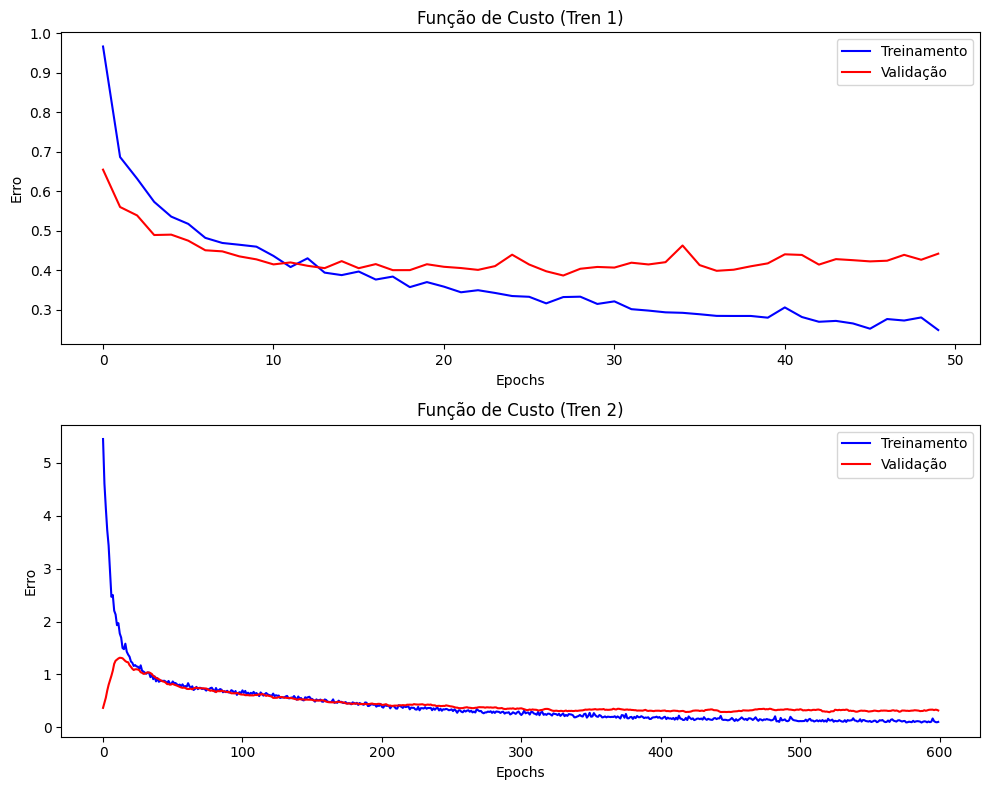

In [ ]:
# Função de custo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# --- Primeiro Subplot (H1_V2) ---
ax1.plot(H1_V3.history['loss'], c='blue', label='Treinamento')
ax1.plot(H1_V3.history['val_loss'], c='red', label='Validação')
ax1.set_ylabel('Erro')
ax1.set_xlabel('Epochs')
ax1.set_title('Função de Custo (Tren 1)')
ax1.legend()

# --- Segundo Subplot (H2_V2) ---
ax2.plot(H2_V3.history['loss'], c='blue', label='Treinamento')
ax2.plot(H2_V3.history['val_loss'], c='red', label='Validação')
ax2.set_ylabel('Erro')
ax2.set_xlabel('Epochs')
ax2.set_title('Função de Custo (Tren 2)')
ax2.legend()

plt.tight_layout()
plt.show()

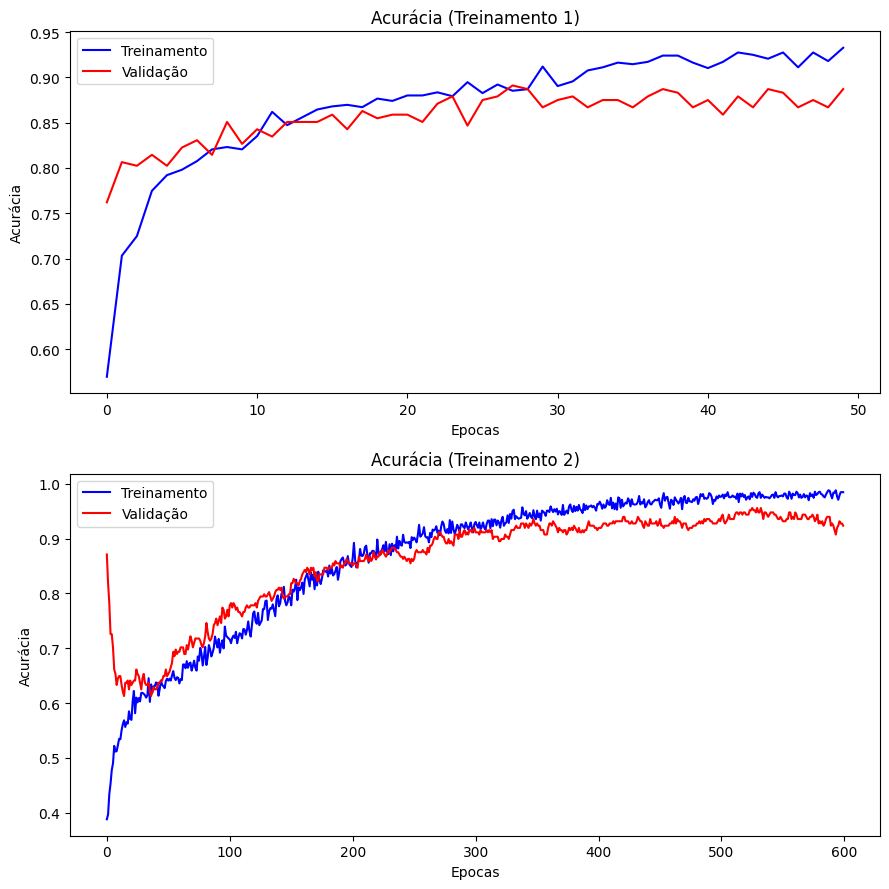

In [ ]:
# Acuracia
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))

# --- Primeiro Subplot (H1_V2) ---
ax1.plot(H1_V3.history['accuracy'], c='blue', label='Treinamento')
ax1.plot(H1_V3.history['val_accuracy'], c='red', label='Validação')
ax1.set_ylabel('Acurácia')
ax1.set_xlabel('Epocas')
ax1.set_title('Acurácia (Treinamento 1)')
ax1.legend()

# --- Segundo Subplot (H2_V2) ---
ax2.plot(H2_V3.history['accuracy'], c='blue', label='Treinamento')
ax2.plot(H2_V3.history['val_accuracy'], c='red', label='Validação')
ax2.set_ylabel('Acurácia')
ax2.set_xlabel('Epocas')
ax2.set_title('Acurácia (Treinamento 2)')
ax2.legend()

plt.tight_layout()
plt.show()

## **Predição**

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


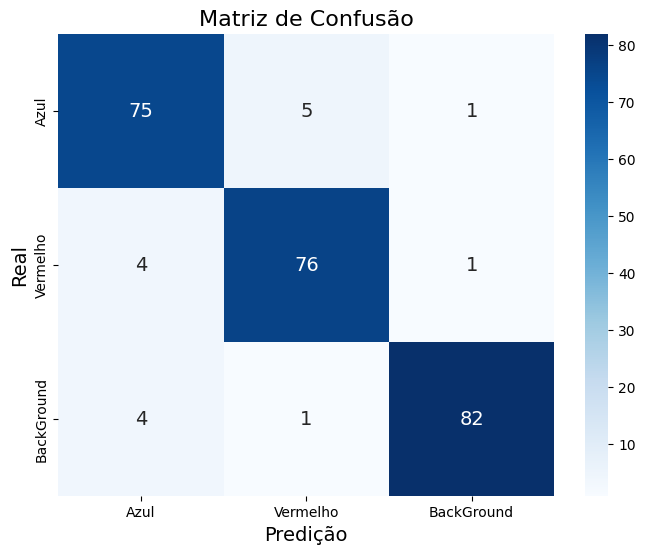

In [ ]:
class_labels = ['Azul', 'Vermelho', "BackGround"]

y_pred = modeloV3.predict(X_teste)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={'size': 14}
)

plt.title('Matriz de Confusão', fontsize=16)
plt.xlabel('Predição', fontsize=14)
plt.ylabel('Real', fontsize=14)
plt.show()


In [ ]:
# -------------------------------
# Accuracy
# -------------------------------
acc = accuracy_score(y_teste, y_pred)
print(f"\nAccuracy: {acc:.4f}\n")

# -------------------------------
# Relatório por classe
# -------------------------------
print("\nRelatório por classe:\n")
print(
    classification_report(
        y_teste,
        y_pred,
        target_names=class_labels,
        digits=4
    )
)



Accuracy: 0.9357


Relatório por classe:

              precision    recall  f1-score   support

        Azul     0.9036    0.9259    0.9146        81
    Vermelho     0.9268    0.9383    0.9325        81
  BackGround     0.9762    0.9425    0.9591        87

    accuracy                         0.9357       249
   macro avg     0.9355    0.9356    0.9354       249
weighted avg     0.9365    0.9357    0.9360       249



# **Modelo MobileNet V2**

In [ ]:
modelV2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
modelV2.trainable = False

modeloV2 = Sequential()
modeloV2.add(modelV2)
modeloV2.add(GlobalAveragePooling2D())
modeloV2.add(Dense(32, activation=LeakyReLU(0.01), kernel_regularizer=l2(0.001)))
modeloV2.add(Dropout(0.4))
modeloV2.add(Dense(3, activation='softmax', kernel_regularizer=l2(0.001)))

modeloV2.compile(optimizer=Adam(0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
modeloV2.summary()

/tmp/ipython-input-2983798402.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  modelV2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,075 (8.77 MB)

 Trainable params: 41,091 (160.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **Callbacks**

In [ ]:
checkpoint1_V2 = ModelCheckpoint('modeloV2.keras', monitor='val_loss', save_best_only=True, mode="min", verbose=1)
checkpoint2_V2 = ModelCheckpoint('modeloV2.keras', monitor='val_loss', save_best_only=True, mode="min", verbose=1)

## **Treinamento 1**

In [ ]:
epocas = 50
H1_V2 = modeloV2.fit(X_treino, y_treino,
                batch_size=16,
                epochs=epocas,
                validation_data=(X_val, y_val),
                callbacks=[checkpoint1_V2]
              )

Epoch 1/50
71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4317 - loss: 1.1145
Epoch 1: val_loss improved from inf to 0.99294, saving model to modeloV2.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.4337 - loss: 1.1127 - val_accuracy: 0.6210 - val_loss: 0.9929
Epoch 2/50
69/73 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5572 - loss: 0.9782
Epoch 2: val_loss improved from 0.99294 to 0.91835, saving model to modeloV2.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5586 - loss: 0.9768 - val_accuracy: 0.6411 - val_loss: 0.9183
Epoch 3/50
70/73 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6348 - loss: 0.9057
Epoch 3: val_loss improved from 0.91835 to 0.88382, saving model to modeloV2.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6344 - loss: 0.9051 - val_accuracy: 0.6290 - val_loss: 0.8838
Epoch 4/50
71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6660 - loss: 0.8541
Epoch 4: val_loss improved from 0.88382 to 0.85705, saving model to

## **Descongelamento e Ajustes**

In [ ]:
modeloV2.load_weights('modeloV2.keras')

#Garantindo que as camadas de treinamento do modelo esteja congelado
modelV2.trainable = False

#Descongelando as 30 ultimas
for layer in modeloV2.layers[-30:]:
    layer.trainable = True

modeloV2.load_weights('modeloV2.keras')
modeloV2.compile(optimizer=Adam(2e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## **Treinamento 2**

In [ ]:
epocas_fase2 = 270
H2_V2 = modeloV2.fit(X_treino, y_treino,
                batch_size=16,
                epochs=epocas_fase2,
                validation_data=(X_val, y_val),
                callbacks=[checkpoint2_V2]
              )

Epoch 1/270
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3851 - loss: 3.0966
Epoch 1: val_loss improved from inf to 1.46171, saving model to modeloV2.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.3849 - loss: 3.0916 - val_accuracy: 0.4234 - val_loss: 1.4617
Epoch 2/270
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4299 - loss: 1.9363
Epoch 2: val_loss did not improve from 1.46171
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.4309 - loss: 1.9336 - val_accuracy: 0.3468 - val_loss: 2.1828
Epoch 3/270
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5177 - loss: 1.6112
Epoch 3: val_loss did not improve from 1.46171
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.5179 - loss: 1.6086 - val_accuracy: 0.3831 - val_loss: 3.4754
Epoch 4/270
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5619 - loss: 1.1884
Epoch 4: val_loss did not improve from 1.46171
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.5621 - loss: 1.1877 - val_accurac

## **Resultados**

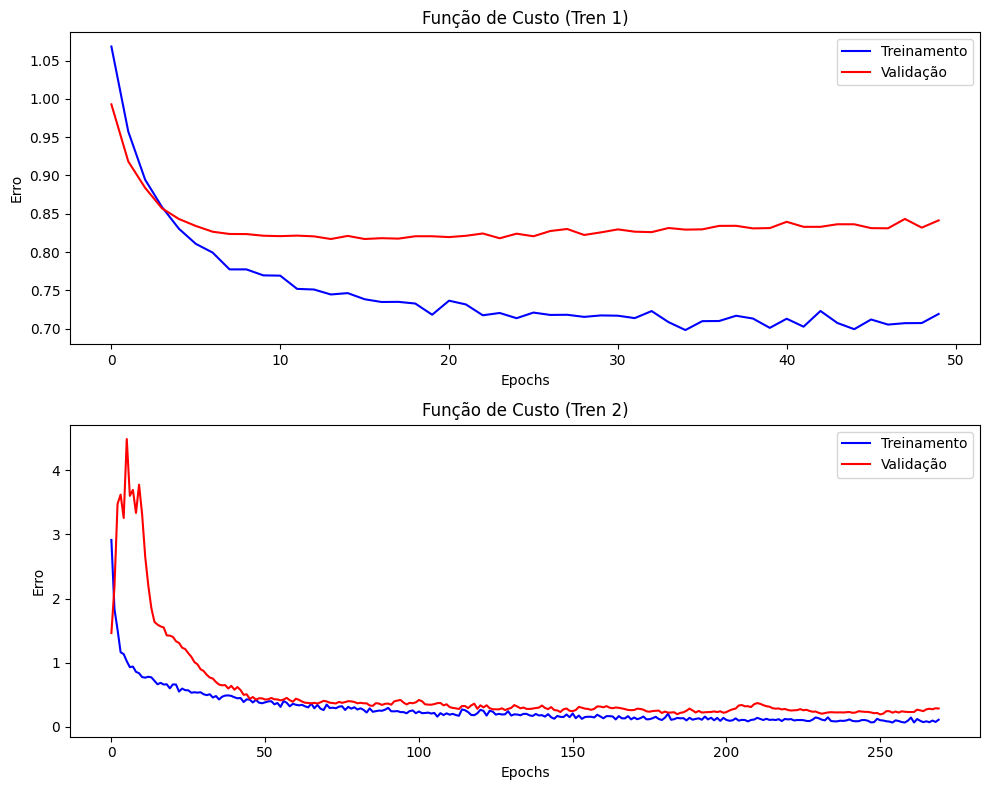

In [ ]:
# Função de custo

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# --- Primeiro Subplot (H1_V2) ---
ax1.plot(H1_V2.history['loss'], c='blue', label='Treinamento')
ax1.plot(H1_V2.history['val_loss'], c='red', label='Validação')
ax1.set_ylabel('Erro')
ax1.set_xlabel('Epochs')
ax1.set_title('Função de Custo (Tren 1)')
ax1.legend()

# --- Segundo Subplot (H2_V2) ---
ax2.plot(H2_V2.history['loss'], c='blue', label='Treinamento')
ax2.plot(H2_V2.history['val_loss'], c='red', label='Validação')
ax2.set_ylabel('Erro')
ax2.set_xlabel('Epochs')
ax2.set_title('Função de Custo (Tren 2)')
ax2.legend()

plt.tight_layout()
plt.show()

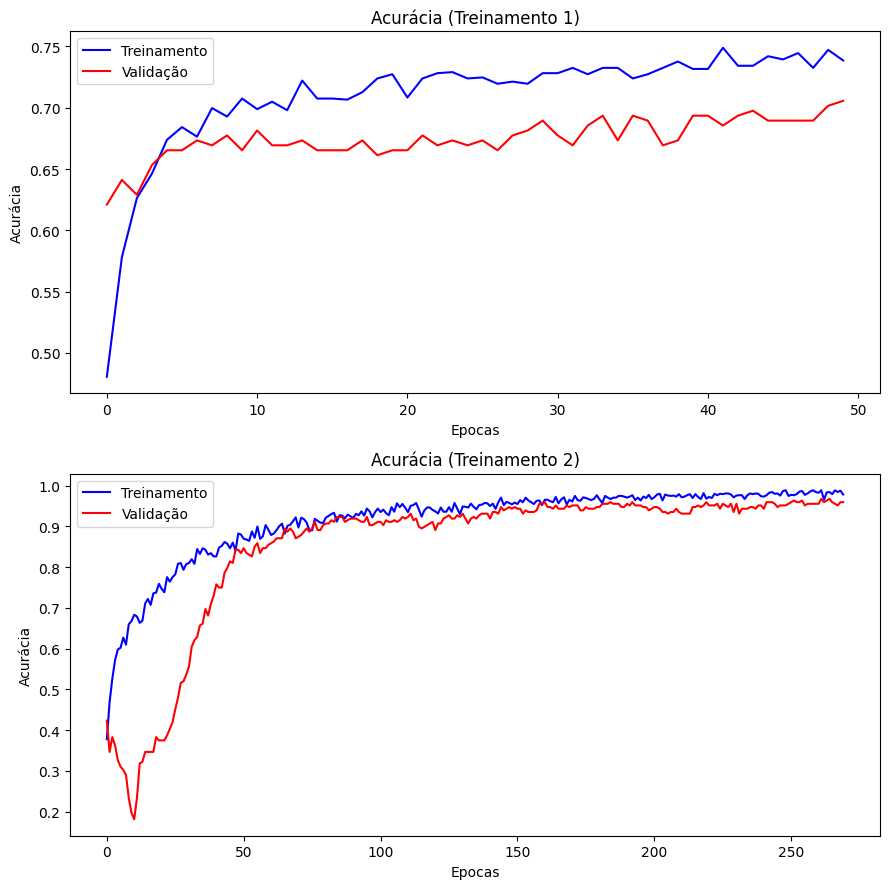

In [ ]:
# Acuracia
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))

# --- Primeiro Subplot (H1_V2) ---
ax1.plot(H1_V2.history['accuracy'], c='blue', label='Treinamento')
ax1.plot(H1_V2.history['val_accuracy'], c='red', label='Validação')
ax1.set_ylabel('Acurácia')
ax1.set_xlabel('Epocas')
ax1.set_title('Acurácia (Treinamento 1)')
ax1.legend()

# --- Segundo Subplot (H2_V2) ---
ax2.plot(H2_V2.history['accuracy'], c='blue', label='Treinamento')
ax2.plot(H2_V2.history['val_accuracy'], c='red', label='Validação')
ax2.set_ylabel('Acurácia')
ax2.set_xlabel('Epocas')
ax2.set_title('Acurácia (Treinamento 2)')
ax2.legend()

plt.tight_layout()
plt.show()

## **Predição**

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step


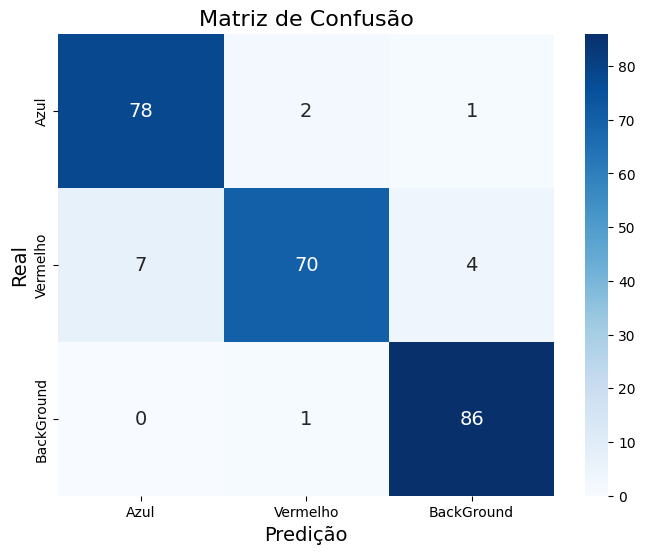

In [ ]:
class_labels = ['Azul', 'Vermelho', "BackGround"]

y_pred = modeloV2.predict(X_teste)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={'size': 14}
)

plt.title('Matriz de Confusão', fontsize=16)
plt.xlabel('Predição', fontsize=14)
plt.ylabel('Real', fontsize=14)
plt.show()


In [ ]:
# -------------------------------
# Accuracy
# -------------------------------
acc = accuracy_score(y_teste, y_pred)
print(f"\nAccuracy: {acc:.4f}\n")

# -------------------------------
# Relatório por classe
# -------------------------------
print("\nRelatório por classe:\n")
print(
    classification_report(
        y_teste,
        y_pred,
        target_names=class_labels,
        digits=4
    )
)



Accuracy: 0.9398


Relatório por classe:

              precision    recall  f1-score   support

        Azul     0.9176    0.9630    0.9398        81
    Vermelho     0.9589    0.8642    0.9091        81
  BackGround     0.9451    0.9885    0.9663        87

    accuracy                         0.9398       249
   macro avg     0.9405    0.9386    0.9384       249
weighted avg     0.9406    0.9398    0.9391       249



# **Modelo Customizado**

## **Arqutetura do Modelo**

In [ ]:
# Modelo CNN simples
model = Sequential([
    # Entrada: imagens 32x32 RGB
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

# Compilação
model.compile(
    optimizer=Adam(1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,107 (652.76 KB)

 Trainable params: 167,107 (652.76 KB)

 Non-trainable params: 0 (0.00 B)

## **Callbacks**

In [ ]:
checkpoint = ModelCheckpoint('model.keras', monitor='val_loss', save_best_only=True, mode="min", verbose=1)

## **Treinamento**

In [ ]:
# Epocas
epocas = 350

# Treinamento
H = model.fit(X_treino, y_treino,
              batch_size=8,
              epochs=epocas,
              verbose=2,
              validation_data=(X_teste, y_teste),
              callbacks=[checkpoint])

Epoch 1/350

Epoch 1: val_loss improved from inf to 8.76772, saving model to model.keras
145/145 - 2s - 17ms/step - accuracy: 0.3210 - loss: 36.1240 - val_accuracy: 0.2851 - val_loss: 8.7677
Epoch 2/350

Epoch 2: val_loss improved from 8.76772 to 8.09534, saving model to model.keras
145/145 - 1s - 10ms/step - accuracy: 0.3417 - loss: 30.8512 - val_accuracy: 0.2932 - val_loss: 8.0953
Epoch 3/350

Epoch 3: val_loss improved from 8.09534 to 6.85354, saving model to model.keras
145/145 - 1s - 10ms/step - accuracy: 0.3374 - loss: 30.1001 - val_accuracy: 0.3414 - val_loss: 6.8535
Epoch 4/350

Epoch 4: val_loss improved from 6.85354 to 6.61131, saving model to model.keras
145/145 - 2s - 11ms/step - accuracy: 0.3667 - loss: 27.8049 - val_accuracy: 0.3855 - val_loss: 6.6113
Epoch 5/350

Epoch 5: val_loss improved from 6.61131 to 6.02707, saving model to model.keras
145/145 - 2s - 16ms/step - accuracy: 0.3589 - loss: 27.1544 - val_accuracy: 0.4297 - val_loss: 6.0271
Epoch 6/350

Epoch 6: val_los

## **Resultados**

### **Erro do Modelo**

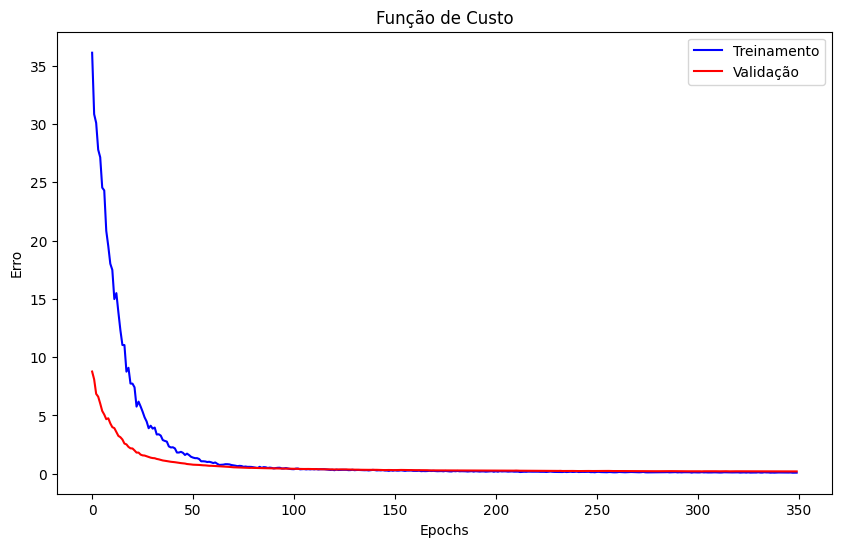

In [ ]:
# Função de custo
plt.figure(figsize=(10, 6))
plt.plot(H.history['loss'], c='blue', label='Treinamento')
plt.plot(H.history['val_loss'], c='red', label='Validação')
plt.ylabel('Erro')
plt.xlabel('Epochs')
plt.title('Função de Custo')
plt.legend()
plt.show()

### **Acuracia do Modelo**

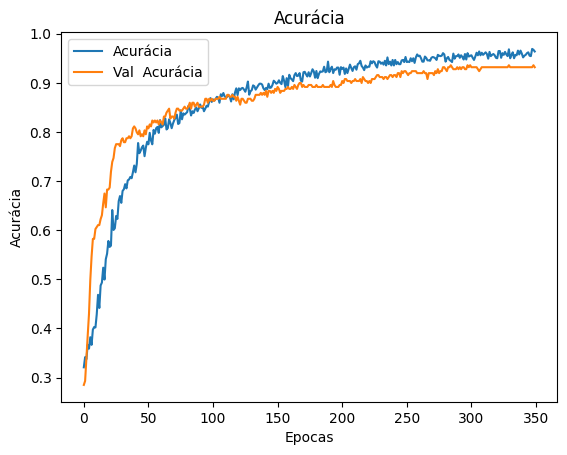

In [ ]:
# Acuracia
plt.plot(H.history['accuracy'], label='Acurácia')
plt.plot(H.history['val_accuracy'], label='Val  Acurácia')
plt.title('Acurácia')
plt.xlabel('Epocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


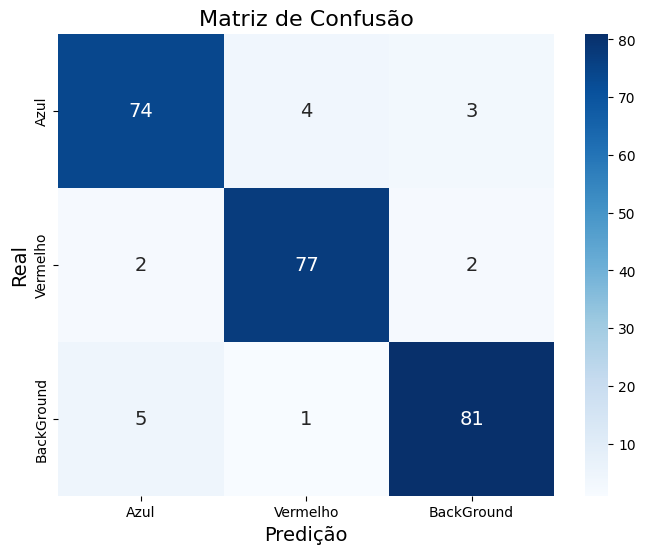

In [ ]:
class_labels = ['Azul', 'Vermelho', "BackGround"]

y_pred = model.predict(X_teste)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={'size': 14}
)

plt.title('Matriz de Confusão', fontsize=16)
plt.xlabel('Predição', fontsize=14)
plt.ylabel('Real', fontsize=14)
plt.show()


In [ ]:
# -------------------------------
# Accuracy
# -------------------------------
acc = accuracy_score(y_teste, y_pred)
print(f"\nAccuracy: {acc:.4f}\n")

# -------------------------------
# Relatório por classe
# -------------------------------
print("\nRelatório por classe:\n")
print(
    classification_report(
        y_teste,
        y_pred,
        target_names=class_labels,
        digits=4
    )
)



Accuracy: 0.9317


Relatório por classe:

              precision    recall  f1-score   support

        Azul     0.9136    0.9136    0.9136        81
    Vermelho     0.9390    0.9506    0.9448        81
  BackGround     0.9419    0.9310    0.9364        87

    accuracy                         0.9317       249
   macro avg     0.9315    0.9317    0.9316       249
weighted avg     0.9317    0.9317    0.9317       249



# **Teste do modelo**

In [ ]:
modelo_test = load_model('modeloV2.keras')

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 330ms/step


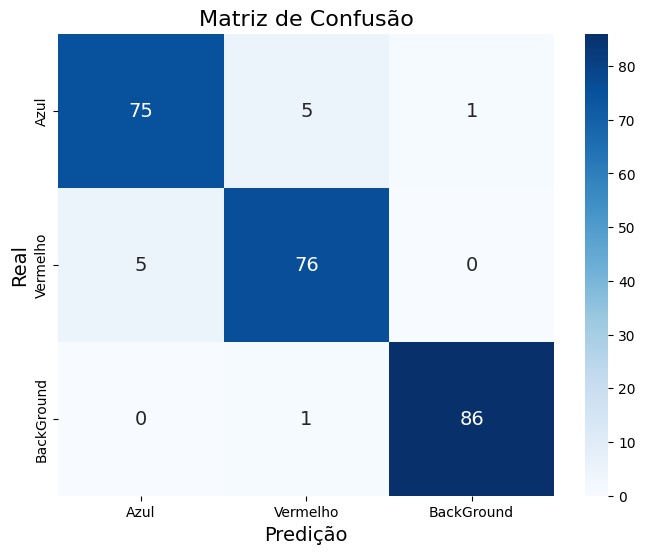

In [ ]:
class_labels = ['Azul', 'Vermelho', "BackGround"]

y_pred = modelo_test.predict(X_teste)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={'size': 14}
)

plt.title('Matriz de Confusão', fontsize=16)
plt.xlabel('Predição', fontsize=14)
plt.ylabel('Real', fontsize=14)
plt.show()


In [ ]:
# -------------------------------
# Accuracy
# -------------------------------
acc = accuracy_score(y_teste, y_pred)
print(f"\nAccuracy: {acc:.4f}\n")

# -------------------------------
# Relatório por classe
# -------------------------------
print("\nRelatório por classe:\n")
print(
    classification_report(
        y_teste,
        y_pred,
        target_names=class_labels,
        digits=4
    )
)



Accuracy: 0.9317


Relatório por classe:

              precision    recall  f1-score   support

        Azul     0.9136    0.9136    0.9136        81
    Vermelho     0.9390    0.9506    0.9448        81
  BackGround     0.9419    0.9310    0.9364        87

    accuracy                         0.9317       249
   macro avg     0.9315    0.9317    0.9316       249
weighted avg     0.9317    0.9317    0.9317       249



# **CNN --> TFLITE**

## **Conversão .Keras --> .tflite**

# ============================================
# 🔄 CONVERSÃO DOS MODELOS PARA TENSORFLOW LITE
# ============================================

"""
Nesta etapa, cada modelo treinado no formato Keras (.keras) é convertido
para diferentes versões do TensorFlow Lite (.tflite), com o objetivo de
avaliar desempenho em ambientes de Edge AI.

Para cada modelo, são geradas três versões:

🔹 1. Modelo Normal (Float32)
- Conversão direta, sem quantização
- Maior precisão
- Maior consumo de memória e processamento

🔹 2. Modelo com Quantização Dinâmica
- Reduz o tamanho do modelo
- Mantém boa precisão
- Otimiza pesos dinamicamente em tempo de execução

🔹 3. Modelo com Quantização Inteira (INT8)
- Máxima otimização para dispositivos embarcados
- Menor tamanho e menor latência
- Requer dataset de calibração (representative_dataset)

⚠️ IMPORTANTE:
- A quantização inteira utiliza dados reais (X_teste) para calibrar os valores
- Isso permite preservar a qualidade do modelo mesmo com redução de precisão

📌 Fluxo do processo:
1. Carrega o modelo Keras (.keras)
2. Aplica diferentes estratégias de conversão
3. Salva os modelos convertidos (.tflite)

📁 Saídas geradas:
- modelo_Normal.tflite
- modelo_Dinamica.tflite
- modelo_Inteira.tflite

⚠️ Esta etapa deve ser repetida para cada modelo (V2, V3 e modelo base),
alterando:
- O arquivo de entrada (.keras)
- Os nomes dos arquivos de saída (.tflite)

Isso garante que todos os modelos tenham versões comparáveis
para análise de desempenho e inferência em edge.
"""

### **Carregar modelo Keras**

In [ ]:
modelo_test = load_model('model.keras')

### **Conversão para Lite normal**

In [ ]:
# Sem quantização
conversor = tf.lite.TFLiteConverter.from_keras_model(modelo_test)
modelo_lite = conversor.convert()

with open('modelo_Normal.tflite', 'wb') as f:
  f.write(modelo_lite)

Saved artifact at '/tmp/tmp4le1_gjr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer_11')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134230380171472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380171664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380174544: TensorSpec(shape=(), dtype=tf.resource, name=None)


### **Conversão com quantização dinamica**

In [ ]:
# Com quantização dinamica
conversor = tf.lite.TFLiteConverter.from_keras_model(modelo_test)
conversor.optimizations = [tf.lite.Optimize.DEFAULT]
modelo_lite = conversor.convert()

with open('modelo_Dinamica.tflite', 'wb') as f:
  f.write(modelo_lite)

Saved artifact at '/tmp/tmpk0puy7ru'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer_11')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134230380171472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380171664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380174544: TensorSpec(shape=(), dtype=tf.resource, name=None)


### **Conversão inteira**

In [ ]:
# --- Função de calibração com X_val ---
def representative_dataset():
    for i in range(min(250, len(X_teste))):
        img = X_teste[i].astype(np.float32)
        img = np.expand_dims(img, axis=0)

        # Se preprocess_input retorna tensor, converta:
        if isinstance(img, tf.Tensor):
            img = img.numpy()

        yield [img]

converter = tf.lite.TFLiteConverter.from_keras_model(modelo_test)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter._experimental_disable_per_channel = False

# --- Converte ---
modelo_quantizado = converter.convert()

# --- Salva ---
with open("modelo_Inteira.tflite", "wb") as f:
    f.write(modelo_quantizado)

Saved artifact at '/tmp/tmpyvtd3y2l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer_11')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134230380171472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380171664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380173968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134230380174544: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## **Carregar modelo TFLITE**

In [ ]:
interpreter = tf.lite.Interpreter(model_path="modelo_lite.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_input_layer_3:0', 'index': 0, 'shape': array([ 1, 32, 32,  3], dtype=int32), 'shape_signature': array([-1, 32, 32,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 176, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


# **Inferência TFLITE**

## **Carregar modelo TFLITE**

In [ ]:
interpreter = tf.lite.Interpreter(model_path="modelo_lite.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_input_layer_3:0', 'index': 0, 'shape': array([ 1, 32, 32,  3], dtype=int32), 'shape_signature': array([-1, 32, 32,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 176, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


## **Escolhendo IMG para teste**

Classificação: 1



<Figure size 600x600 with 0 Axes>

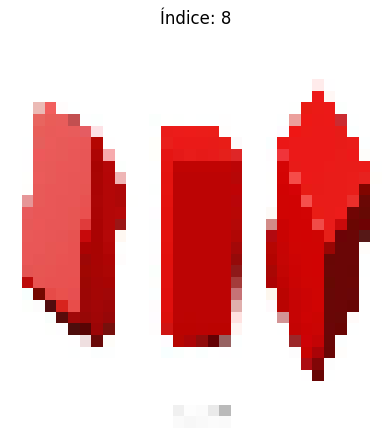

In [ ]:
# Imagem de Teste

# Escolha o índice da imagem 0 - 323
indice_selecionado = 8

print(f"Classificação: {y_teste[indice_selecionado]}\n")

img = X_teste[indice_selecionado]

plt.figure(figsize=(6, 6))

plt.matshow(img)

plt.title(f"Índice: {indice_selecionado}")
plt.axis('off')

plt.show()

## **Preparação Para Float, necessario para quantização normal ou dinâmica**

In [ ]:
# Pre preparação da imagem
img = img.astype(np.float32z)
img = preprocess_input(img)
img = np.expand_dims(img, axis=0)

# Informações da imagem
print(f"Tipo: {type(img)}")
print(f"Dtype: {img.dtype}")
print(f"Shape: {img.shape}")

Tipo: <class 'numpy.ndarray'>
Dtype: int8
Shape: (1, 32, 32, 3)


## **Chamando o Invoke**

In [ ]:
interpreter.set_tensor(input_details[0]['index'], img)

interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])[0][0]

print(np.around(output_data))


1.0


## **Preparação da img para inteiro, necessario para quantização inteira**

In [ ]:
# Pre preparação da imagem
scale_in, zero_in = input_details[0]['quantization']
scale_out, zero_out = output_details[0]['quantization']

img = img.astype(np.float32)
img = preprocess_input(img)
img = np.expand_dims(img, axis=0)

img = ((img / scale_in) + zero_in).astype(np.int8)

# Informações da imagem
print(f"Tipo: {type(img)}")
print(f"Dtype: {img.dtype}")
print(f"Shape: {img.shape}")

Tipo: <class 'numpy.ndarray'>
Dtype: int8
Shape: (1, 32, 32, 3)


## **Chamando o Invoke**

In [ ]:
interpreter.set_tensor(input_details[0]['index'], img)

interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])[0][0]

output_float = (float(output_data) - float(zero_out)) * float(scale_out)

print(np.around(output_float))


1.0


146832# ESP32-S3 DevKitC 1 - Informações e Especificações
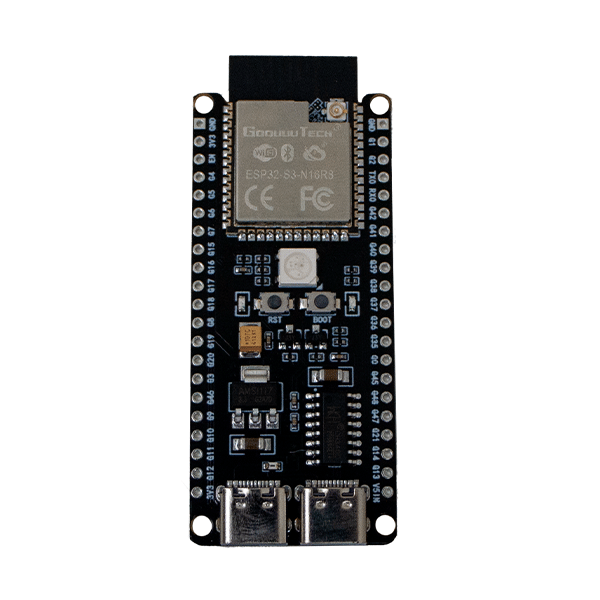

---

## Sobre a Placa

A **ESP32-S3 DevKitC 1** é uma placa de desenvolvimento baseada no microcontrolador ESP32-S3, projetada para aplicações que exigem alto desempenho, conectividade Wi-Fi e Bluetooth, e capacidade de processamento eficiente. Ela é ideal para projetos de IoT, automação, robótica e prototipagem rápida.

---

## Informações de Memória (Teste em Codigo)



===== ESP32-S3 MEMORY INFO ===== <br>
Free heap: 361964 bytes<br>
Total heap: 397084 bytes<br>
Free internal RAM: 361964 bytes<br>
Flash size (bytes): 16777216<br>
Flash speed (Hz): 80000000<br>

===== INTERNAL MEMORY INFO ===== <br>
Free internal RAM: 361972 bytes<br>
Largest free block (internal): 303092 bytes



Esses dados podem variar dependendo do programa carregado na placa e da utilização de recursos.

---

## Especificações Técnicas (Fabricante)

- **Microcontrolador:** ESP32-S3-WROOM-1-N16R8  
- **CPU:** Xtensa® Dual-Core 32-bit LX7  
- **Velocidade do Clock:** 240 MHz  
- **Conectividade:**
  - Wi-Fi 802.11 b/g/n 2.4 GHz  
  - Suporte a Wi-Fi Direct (P2P), P2P Discovery, P2P Group Owner mode, P2P Power Management  
  - Bluetooth BLE 5  
- **Pinos I/O Digitais:** 36  
- **Portas Analógicas:** 16  
- **Número Total de Pinos:** 42  
- **DAC:** 2  
- **Tensão de Operação:** 3,3 VDC  
- **Tensão de Alimentação:** 5 VDC  
- **Corrente Máxima nos Pinos I/O:** 20 mA  
- **Memória Flash:** 16 MB  
- **PSRAM:** 8 MB  
- **SRAM:** 512 KB  
- **ROM:** 384 KB  
- **Dimensões:** 68 mm x 28 mm x 4,5 mm (desconsiderando os pinos)

---

## Observações

- Esta placa é compatível com o **ESP-IDF**, **Arduino IDE** e **MicroPython**, tornando-a muito versátil para diferentes tipos de projetos.  
- O desempenho real pode variar dependendo do uso de Wi-Fi, Bluetooth e periféricos conectados.  
- É recomendável sempre verificar o consumo de memória para evitar travamentos em aplicações mais complexas.

---


# ESP32-S3 DevKitC 1 - Informações e Especificações
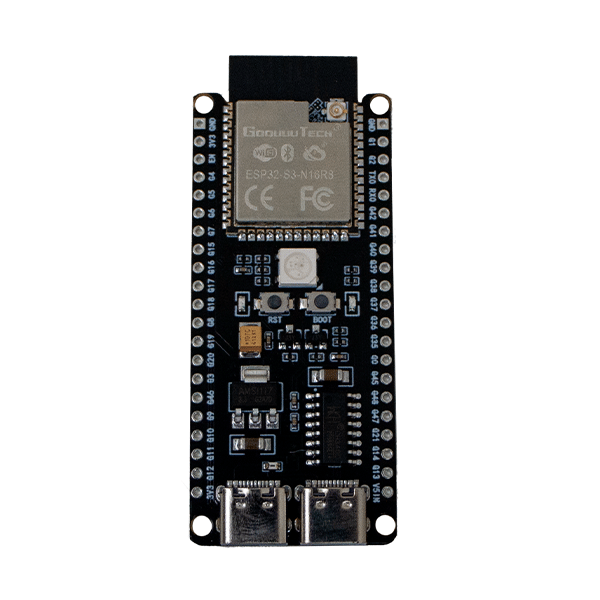

---

## Sobre a Placa

A **ESP32-S3 DevKitC 1** é uma placa de desenvolvimento baseada no microcontrolador ESP32-S3, projetada para aplicações que exigem alto desempenho, conectividade Wi-Fi e Bluetooth, e capacidade de processamento eficiente. Ela é ideal para projetos de IoT, automação, robótica e prototipagem rápida.

---

## Informações de Memória (Teste em Codigo)



===== ESP32-S3 MEMORY INFO ===== <br>
Free heap: 361964 bytes<br>
Total heap: 397084 bytes<br>
Free internal RAM: 361964 bytes<br>
Flash size (bytes): 16777216<br>
Flash speed (Hz): 80000000<br>

===== INTERNAL MEMORY INFO ===== <br>
Free internal RAM: 361972 bytes<br>
Largest free block (internal): 303092 bytes



Esses dados podem variar dependendo do programa carregado na placa e da utilização de recursos.

---

## Especificações Técnicas (Fabricante)

- **Microcontrolador:** ESP32-S3-WROOM-1-N16R8  
- **CPU:** Xtensa® Dual-Core 32-bit LX7  
- **Velocidade do Clock:** 240 MHz  
- **Conectividade:**
  - Wi-Fi 802.11 b/g/n 2.4 GHz  
  - Suporte a Wi-Fi Direct (P2P), P2P Discovery, P2P Group Owner mode, P2P Power Management  
  - Bluetooth BLE 5  
- **Pinos I/O Digitais:** 36  
- **Portas Analógicas:** 16  
- **Número Total de Pinos:** 42  
- **DAC:** 2  
- **Tensão de Operação:** 3,3 VDC  
- **Tensão de Alimentação:** 5 VDC  
- **Corrente Máxima nos Pinos I/O:** 20 mA  
- **Memória Flash:** 16 MB  
- **PSRAM:** 8 MB  
- **SRAM:** 512 KB  
- **ROM:** 384 KB  
- **Dimensões:** 68 mm x 28 mm x 4,5 mm (desconsiderando os pinos)

---

## Observações

- Esta placa é compatível com o **ESP-IDF**, **Arduino IDE** e **MicroPython**, tornando-a muito versátil para diferentes tipos de projetos.  
- O desempenho real pode variar dependendo do uso de Wi-Fi, Bluetooth e periféricos conectados.  
- É recomendável sempre verificar o consumo de memória para evitar travamentos em aplicações mais complexas.

---


# **Comparação dos Modelos: V2, V3 e Customizado**

## **Inferência para quantização normal e dinâmica**

In [ ]:
def inferencia_tflite_float(model_path, X_teste, input_details, output_details):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_index = input_details[0]['index']
    output_index = output_details[0]['index']

    predicoes = []
    for i in range(len(X_teste)):
        img = X_teste[i]
        img = img.astype(np.float32)
        img = np.expand_dims(img, axis=0)
        interpreter.set_tensor(input_index, img)
        interpreter.invoke()

        output_data = interpreter.get_tensor(output_index)[0]
        class_pred = np.argmax(output_data)
        predicoes.append(class_pred)

    return np.array(predicoes)

## **Inferência para quantização inteira**

In [ ]:
def inferencia_tflite_int8(model_path, X_teste):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    scale_in, zero_in = input_details[0]['quantization']
    scale_out, zero_out = output_details[0]['quantization']
    input_index = input_details[0]['index']
    output_index = output_details[0]['index']

    predicoes = []
    for i in range(len(X_teste)):
        img = X_teste[i]
        img = img.astype(np.float32)
        img = np.expand_dims(img, axis=0)

        img_quant = ((img / scale_in) + zero_in).astype(input_details[0]['dtype'])

        interpreter.set_tensor(input_index, img_quant)
        interpreter.invoke()

        output_quant = interpreter.get_tensor(output_index)[0]

        output_float = (output_quant.astype(np.float32) - float(zero_out)) * float(scale_out)

        class_pred = np.argmax(output_float)
        predicoes.append(class_pred)

    return np.array(predicoes)

In [ ]:
def inferencia_modelo_keras(model_path, X_teste):
    modelo_test = load_model(model_path)
    y_pred = modelo_test.predict(X_teste)
    y_pred = np.argmax(y_pred, axis=1)
    return y_pred

# ============================================
# 📦 MODELOS UTILIZADOS NO EXPERIMENTO
# ============================================

"""
Antes de executar esta etapa, certifique-se de que todos os modelos foram gerados.

O experimento utiliza três modelos principais no formato Keras (.keras),
e para cada um deles existem versões convertidas para TensorFlow Lite (.tflite):

🔹 Modelo V2:
    - modeloV2.keras
    - v2_Normal.tflite      (float32)
    - v2_Dinamica.tflite   (quantização dinâmica)
    - v2_Inteira.tflite    (quantização int8)

🔹 Modelo V3:
    - modeloV3.keras
    - v3_Normal.tflite
    - v3_Dinamica.tflite
    - v3_Inteira.tflite

🔹 Modelo Base:
    - model.keras
    - modelo_Normal.tflite
    - modelo_Dinamica.tflite
    - modelo_Inteira.tflite

Todos esses modelos estão disponíveis na pasta:
📁 /modelos
em: https://github.com/Keltonmd/EdgeBoxAI/tree/main/modelos

Caso não estejam presentes, execute a etapa de treinamento e conversão antes de continuar.

Este procedimento garante a reprodutibilidade dos experimentos.
"""

## **Plotar Matrizes de Confusão**

In [ ]:
def plot_confusion_matrix(cm, model_name, class_labels, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels,
                annot_kws={'size': 10},
                ax=ax, cbar=False)
    ax.set_title(f'CM: {model_name}', fontsize=12)
    ax.set_xlabel('Predição')
    ax.set_ylabel('Real')

## **Comparação**

In [ ]:
def comparar_modelos(modelos_config, X_teste, y_teste, class_labels):
    resultados_metricas = []

    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.flatten()

    for idx, config in enumerate(modelos_config):
        model_name = config['nome']
        model_path = config['caminho']
        model_type = config['tipo']

        try:
            if model_type == 'int8':
                predicoes = inferencia_tflite_int8(model_path, X_teste)
            elif model_type == 'keras':
                predicoes = inferencia_modelo_keras(model_path, X_teste)
            else:
                temp_interpreter = tf.lite.Interpreter(model_path=model_path)
                temp_interpreter.allocate_tensors()
                input_details = temp_interpreter.get_input_details()
                output_details = temp_interpreter.get_output_details()
                predicoes = inferencia_tflite_float(model_path, X_teste, input_details, output_details)

        except Exception as e:
            print(f"ERRO ao carregar/inferir {model_name}: {e}")
            continue

        cm = confusion_matrix(y_teste, predicoes)

        relatorio = classification_report(y_teste, predicoes, target_names=class_labels, output_dict=True)
        acuracia = accuracy_score(y_teste, predicoes)

        resultados_metricas.append({
            'Modelo': model_name,
            'Acurácia': acuracia,
            'Precisão (Média)': relatorio['macro avg']['precision'],
            'Recall (Média)': relatorio['macro avg']['recall'],
            'F1-Score (Média)': relatorio['macro avg']['f1-score'],
            'CM': cm
        })

        plot_confusion_matrix(cm, model_name, class_labels, axes[idx])

    plt.tight_layout()
    plt.show()

    return resultados_metricas

## **Resultado**

### **Desativar Warnings. Recomendo migrrar para o ai_edge_litert**

In [ ]:
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="tensorflow.lite.python.interpreter"
)

tf.get_logger().setLevel('ERROR')

### **Matriz de Confusão**

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 309ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


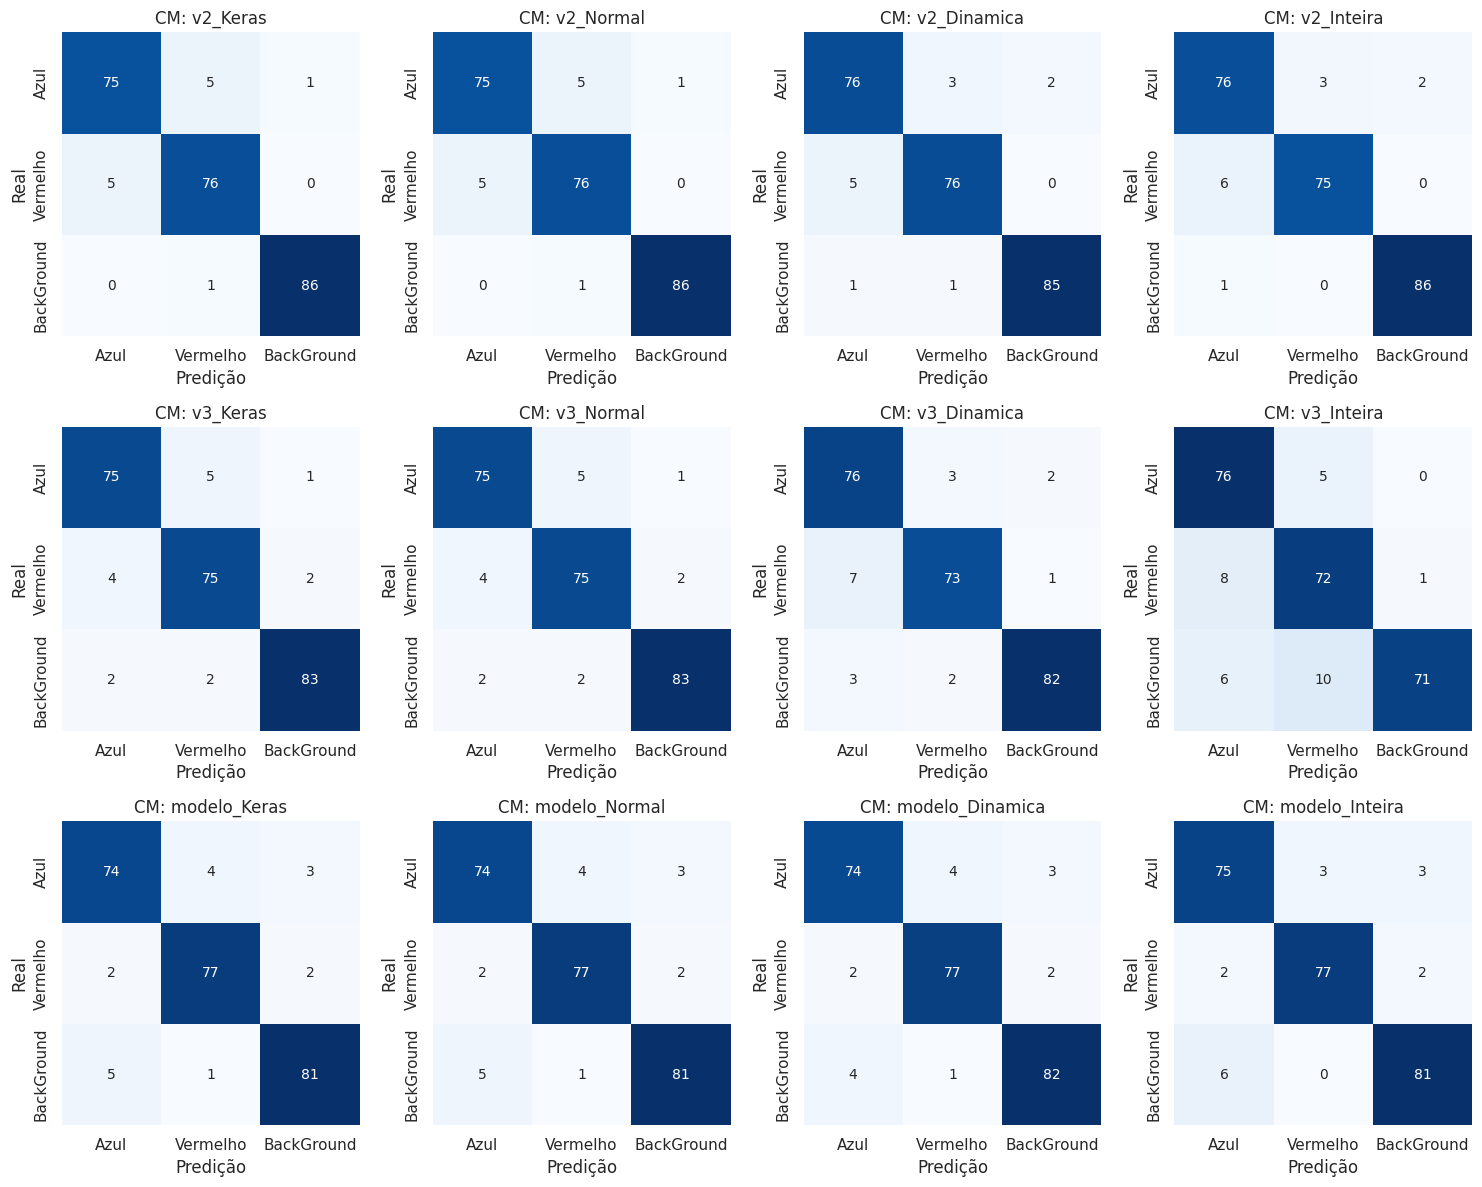

In [ ]:
modelos_a_comparar = [
    {'nome': 'v2_Keras', 'caminho': 'modeloV2.keras', 'tipo': 'keras'},
    {'nome': 'v2_Normal', 'caminho': 'v2_Normal.tflite', 'tipo': 'float'},
    {'nome': 'v2_Dinamica', 'caminho': 'v2_Dinamica.tflite', 'tipo': 'float'},
    {'nome': 'v2_Inteira', 'caminho': 'v2_Inteira.tflite', 'tipo': 'int8'},


    {'nome': 'v3_Keras', 'caminho': 'modeloV3.keras', 'tipo': 'keras'},
    {'nome': 'v3_Normal', 'caminho': 'v3_Normal.tflite', 'tipo': 'float'},
    {'nome': 'v3_Dinamica', 'caminho': 'v3_Dinamica.tflite', 'tipo': 'float'},
    {'nome': 'v3_Inteira', 'caminho': 'v3_Inteira.tflite', 'tipo': 'int8'},


    {'nome': 'modelo_Keras', 'caminho': 'model.keras', 'tipo': 'keras'},
    {'nome': 'modelo_Normal', 'caminho': 'modelo_Normal.tflite', 'tipo': 'float'},
    {'nome': 'modelo_Dinamica', 'caminho': 'modelo_Dinamica.tflite', 'tipo': 'float'},
    {'nome': 'modelo_Inteira', 'caminho': 'modelo_Inteira.tflite', 'tipo': 'int8'},
]

class_labels = ['Azul', 'Vermelho', 'BackGround']

resultados = comparar_modelos(modelos_a_comparar, X_teste, y_teste, class_labels)

### **Metricas**

In [ ]:
# ============================================================
# 1) Converter 'resultados' em DataFrame base
# ============================================================

df_resultados = pd.DataFrame(resultados)

if "CM" in df_resultados.columns:
    df_resultados = df_resultados.drop(columns=["CM"])

df_resultados = df_resultados.set_index("Modelo")


# ============================================================
# 2) Adicionar tamanho dos arquivos TFLite
# ============================================================

tamanhos_dict = {}

for config in modelos_a_comparar:
    nome = config['nome']
    caminho = config['caminho']

    if os.path.exists(caminho):
        bytes_val = os.path.getsize(caminho)
        kb_val = bytes_val / 1024
        mb_val = bytes_val / (1024 * 1024)
        tamanhos_dict[nome] = {'Tamanho (KB)': kb_val, 'Tamanho (MB)': mb_val}
    else:
        print(f"❌ Arquivo não encontrado: {caminho}")
        tamanhos_dict[nome] = {'Tamanho (KB)': 0, 'Tamanho (MB)': 0}

df_tamanhos = pd.DataFrame.from_dict(tamanhos_dict, orient='index')


# ============================================================
# 3) Abrir arquivo CSV: arena_results.csv
# ============================================================

csv_path = "arena_results.csv"

if os.path.exists(csv_path):
    df_arena = pd.read_csv(csv_path)
    df_arena = df_arena.set_index("modelo")
    df_arena = df_arena.rename(columns={
        "arena_kb": "Arena (KB)",
        "arena_mb": "Arena (MB)",
        "reducao_percent": "Arena Redução (%)"
    })
else:
    print("⚠️ CSV 'arena_results.csv' não foi encontrado!")
    df_arena = pd.DataFrame()


# ============================================================
# 4) Juntar tudo em um único DataFrame
# ============================================================

df_final = df_resultados.join(df_tamanhos, how="left")

if not df_arena.empty:
    df_final = df_final.join(df_arena, how="left")


# ============================================================
# 5) Calcular redução de tamanho (KB) em relação ao modelo _Normal
# ============================================================

def calcular_reducao(row):
    try:
        partes = row.name.split('_')
        versao = partes[0]       # modelo, v2, v3
        base_nome = f"{versao}_Keras"

        tamanho_base = df_final.loc[base_nome, 'Tamanho (KB)']

        if tamanho_base == 0:
            return 0.0

        return (1 - (row['Tamanho (KB)'] / tamanho_base)) * 100

    except:
        return 0.0

df_final["Redução (%)"] = df_final.apply(calcular_reducao, axis=1)


# ============================================================
# 6) Exibir tabela final e organizada
# ============================================================

colunas_exibicao = [
    'Acurácia',
    'F1-Score (Média)',
    'Tamanho (KB)',
    'Tamanho (MB)',
    'Arena (KB)',
    'Arena (MB)',
    'Arena Redução (%)',
    'Redução (%)'
]

colunas_existentes = [c for c in colunas_exibicao if c in df_final.columns]

print("\n### 🔥 Tabela Final Consolidada ###")
print(df_final[colunas_existentes].to_markdown(floatfmt=".4f"))



### 🔥 Tabela Final Consolidada ###
| Modelo          |   Acurácia |   F1-Score (Média) |   Tamanho (KB) |   Tamanho (MB) |   Redução (%) |
|:----------------|-----------:|-------------------:|---------------:|---------------:|--------------:|
| v2_Keras        |     0.9518 |             0.9509 |     27366.3350 |        26.7249 |        0.0000 |
| v2_Normal       |     0.9518 |             0.9509 |      8817.7734 |         8.6111 |       67.7788 |
| v2_Dinamica     |     0.9518 |             0.9512 |      2488.9375 |         2.4306 |       90.9051 |
| v2_Inteira      |     0.9518 |             0.9510 |      2687.2891 |         2.6243 |       90.1803 |
| v3_Keras        |     0.9357 |             0.9352 |     11788.7402 |        11.5124 |        0.0000 |
| v3_Normal       |     0.9357 |             0.9352 |      3712.2930 |         3.6253 |       68.5098 |
| v3_Dinamica     |     0.9277 |             0.9273 |      1097.4062 |         1.0717 |       90.6911 |
| v3_Inteira      |     0.87

### **Preparação**

In [ ]:
df_plot = df_final.reset_index()

df_plot['Arquitetura'] = df_plot['Modelo'].apply(lambda x: x.split('_')[0])
df_plot['Tipo'] = df_plot['Modelo'].apply(lambda x: x.split('_')[1])

ordem_tipos = ['Keras','Normal', 'Dinamica', 'Inteira']
df_plot['Tipo'] = pd.Categorical(df_plot['Tipo'], categories=ordem_tipos, ordered=True)

# ===== NOVAS COLUNAS =====
df_plot['Arena (KB)'] = df_plot['arena_bytes'] / 1024
df_plot['Arena (MB)'] = df_plot['arena_bytes'] / (1024**2)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})


In [ ]:
df_plot

,Modelo,Acurácia,Precisão (Média),Recall (Média),F1-Score (Média),Tamanho (KB),Tamanho (MB),arena_bytes,input_bytes,output_bytes,Redução (%),Arquitetura,Tipo,Arena (KB),Arena (MB)
0,v2_Keras,0.951807,0.950945,0.950901,0.950899,27366.334961,26.724936,NaN,NaN,NaN,0.000000,v2,Keras,NaN,NaN
1,v2_Normal,0.951807,0.950945,0.950901,0.950899,8817.773438,8.611107,275504.0,12288.0,12.0,67.778756,v2,Normal,269.046875,0.262741
2,v2_Dinamica,0.951807,0.951280,0.951185,0.951209,2488.937500,2.430603,275504.0,12288.0,12.0,90.905112,v2,Dinamica,269.046875,0.262741
3,v2_Inteira,0.951807,0.951491,0.950901,0.951028,2687.289062,2.624306,183408.0,3072.0,3.0,90.180311,v2,Inteira,179.109375,0.174911
4,v3_Keras,0.935743,0.935225,0.935292,0.935236,11788.740234,11.512442,NaN,NaN,NaN,0.000000,v3,Keras,NaN,NaN
5,v3_Normal,0.935743,0.935225,0.935292,0.935236,3712.292969,3.625286,126672.0,12288.0,12.0,68.509842,v3,Normal,123.703125,0.120804
6,v3_Dinamica,0.927711,0.928108,0.927345,0.927302,1097.406250,1.071686,126672.0,12288.0,12.0,90.691064,v3,Dinamica,123.703125,0.120804
7,v3_Inteira,0.879518,0.886047,0.881084,0.879705,1202.835938,1.174644,102208.0,3072.0,3.0,89.796739,v3,Inteira,99.812500,0.097473
8,modelo_Keras,0.931727,0.931488,0.931744,0.931594,1996.917969,1.950115,NaN,NaN,NaN,0.000000,modelo,Keras,NaN,NaN
9,modelo_Normal,0.931727,0.931488,0.931744,0.931594,656.101562,0.640724,146832.0,12288.0,12.0,67.144291,modelo,Normal,143.390625,0.140030


### **Grafico comparativo**

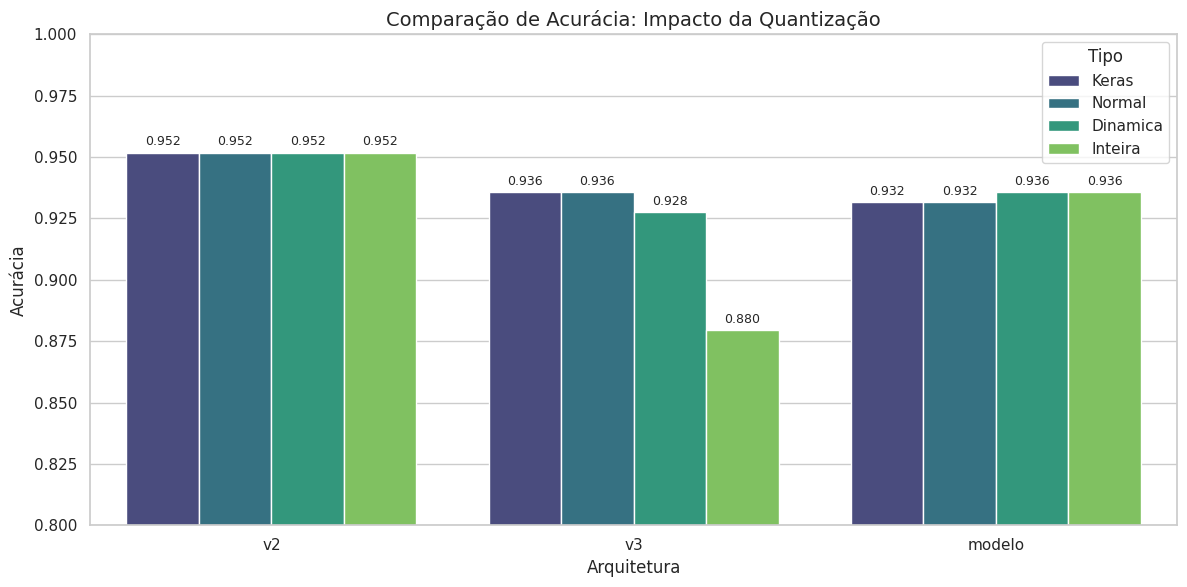

In [ ]:
plt.figure(figsize=(12, 6))
ax1 = sns.barplot(data=df_plot, x='Arquitetura', y='Acurácia', hue='Tipo', palette='viridis')
plt.ylim(0.8, 1.0)
plt.title('Comparação de Acurácia: Impacto da Quantização', fontsize=14)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

### **Grafico de Sensibilidade**

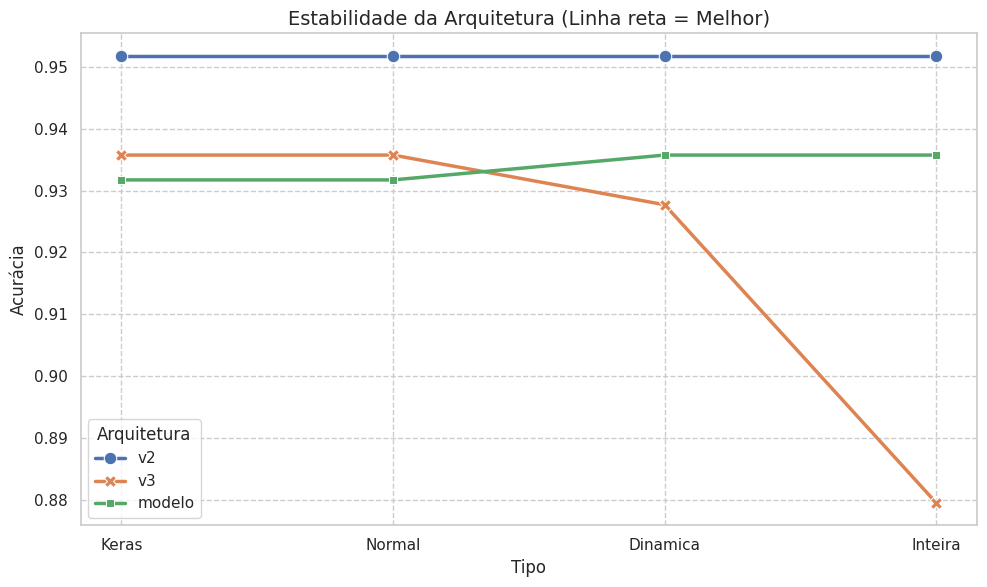

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot, x='Tipo', y='Acurácia', hue='Arquitetura', style='Arquitetura',
    markers=True, dashes=False, linewidth=2.5, markersize=9, palette='deep'
)
plt.title('Estabilidade da Arquitetura (Linha reta = Melhor)', fontsize=14)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

### **Grafico de Perdas**

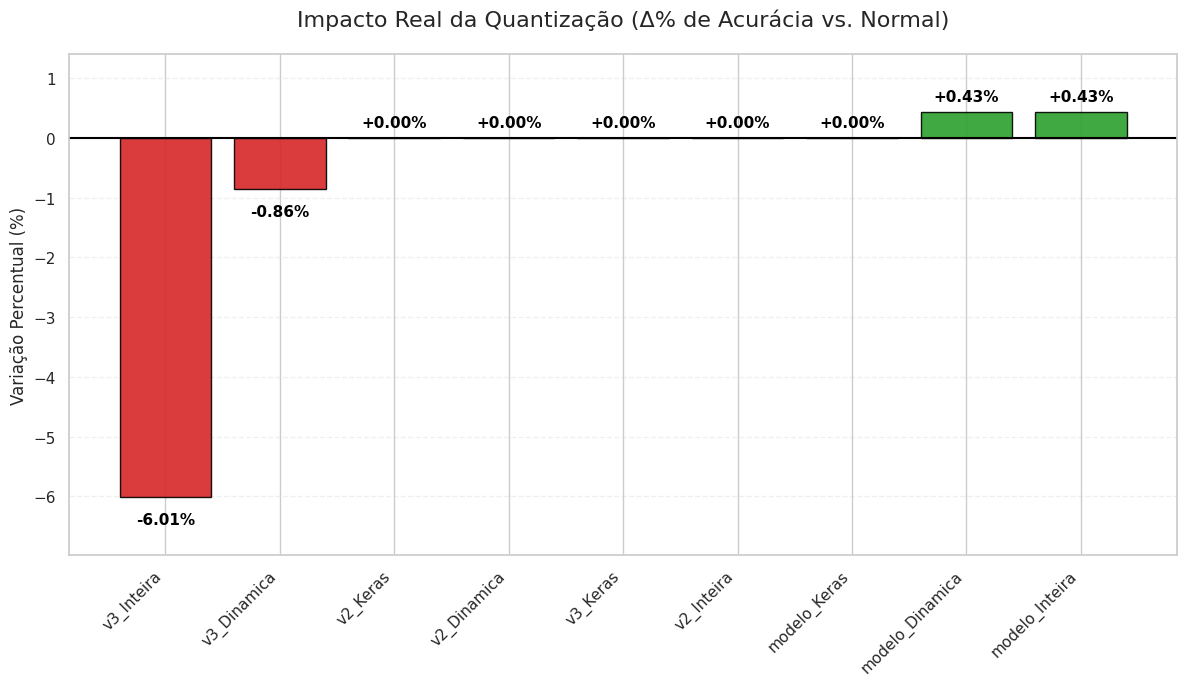

In [ ]:
df_delta = df_plot.copy()

df_delta[['Arquitetura', 'Tipo']] = df_delta['Modelo'].str.rsplit('_', n=1, expand=True)

bases_map = df_delta[df_delta['Tipo'] == 'Normal'].set_index('Arquitetura')['Acurácia'].to_dict()

def calcular_delta_robusto(row):
    if row['Tipo'] == 'Normal':
        return np.nan

    acc_base = bases_map.get(row['Arquitetura'])

    if acc_base is None:
        return np.nan

    return ((row['Acurácia'] - acc_base) / acc_base) * 100

df_delta["Delta (%)"] = df_delta.apply(calcular_delta_robusto, axis=1)

df_delta_plot = df_delta.dropna(subset=["Delta (%)"]).sort_values("Delta (%)")

plt.figure(figsize=(12, 7))

cores = ['#2ca02c' if d >= 0 else '#d62728' for d in df_delta_plot['Delta (%)']]

bars = plt.bar(
    df_delta_plot['Modelo'],
    df_delta_plot['Delta (%)'],
    color=cores,
    edgecolor='black',
    alpha=0.9
)

plt.axhline(0, color='black', linewidth=1.5)
plt.title("Impacto Real da Quantização (Δ% de Acurácia vs. Normal)", fontsize=16, pad=20)
plt.ylabel("Variação Percentual (%)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

y_max = df_delta_plot['Delta (%)'].max()
y_min = df_delta_plot['Delta (%)'].min()
margin = (y_max - y_min) * 0.15 if y_max != y_min else 1.0
plt.ylim(y_min - margin, y_max + margin)

offset = (y_max - y_min) * 0.02
for bar in bars:
    height = bar.get_height()
    label_y_pos = height + offset if height >= 0 else height - offset * 2

    plt.text(
        bar.get_x() + bar.get_width()/2,
        label_y_pos,
        f"{height:+.2f}%",
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Grafico de Calor**

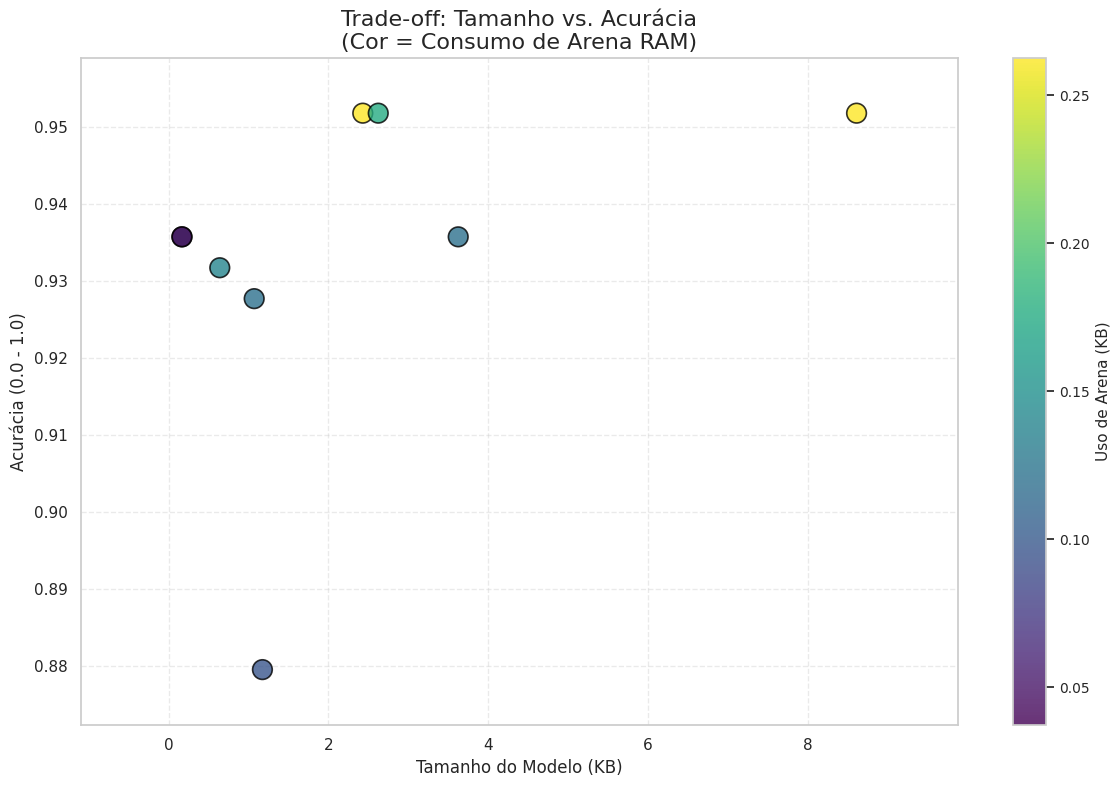

In [ ]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df_plot['Tamanho (MB)'],
    df_plot['Acurácia'],
    s=200,
    c=df_plot['Arena (MB)'],
    cmap='viridis',
    alpha=0.8,
    edgecolor='black',
    linewidth=1.2,
    zorder=2
)

for i, row in df_plot.iterrows():
    plt.annotate(
        row['Modelo'],
        xy=(row['Tamanho (KB)'], row['Acurácia']),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        alpha=0.9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.6)
    )

plt.title("Trade-off: Tamanho vs. Acurácia\n(Cor = Consumo de Arena RAM)", fontsize=16)
plt.xlabel("Tamanho do Modelo (MB)", fontsize=12)
plt.ylabel("Acurácia (0.0 - 1.0)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4, zorder=1)

plt.margins(x=0.15, y=0.1)

cbar = plt.colorbar(scatter)
cbar.set_label("Uso de Arena (MB)", fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

### **Grafico Acuracia X Tamanho do modelo**

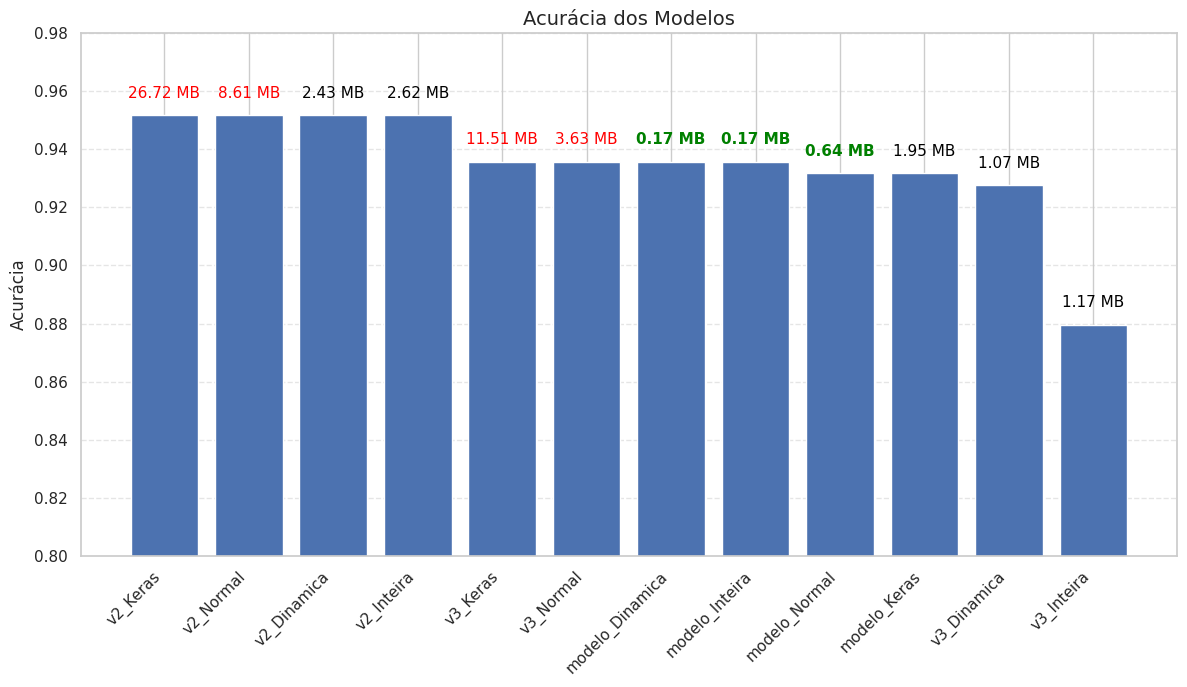

In [ ]:
df_v = df_plot.sort_values('Acurácia', ascending=False)

plt.figure(figsize=(12, 7))

barras = plt.bar(df_v['Modelo'], df_v['Acurácia'])

plt.ylim(0.8, 0.98)
plt.title('Acurácia dos Modelos', fontsize=14)
plt.ylabel('Acurácia')

plt.xticks(rotation=45, ha='right')  # melhora leitura

for i, bar in enumerate(barras):
    tamanho = df_v['Tamanho (MB)'].iloc[i]
    acc = df_v['Acurácia'].iloc[i]

    cor_texto = 'red' if tamanho > 3 else ('green' if tamanho < 1 else 'black')
    weight = 'bold' if tamanho < 1 else 'normal'

    plt.text(
        bar.get_x() + bar.get_width()/2,  # centro da barra
        acc + 0.005,                     # acima da barra
        f'{tamanho:.2f} MB',
        ha='center',
        va='bottom',
        color=cor_texto,
        fontsize=11,
        fontweight=weight
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


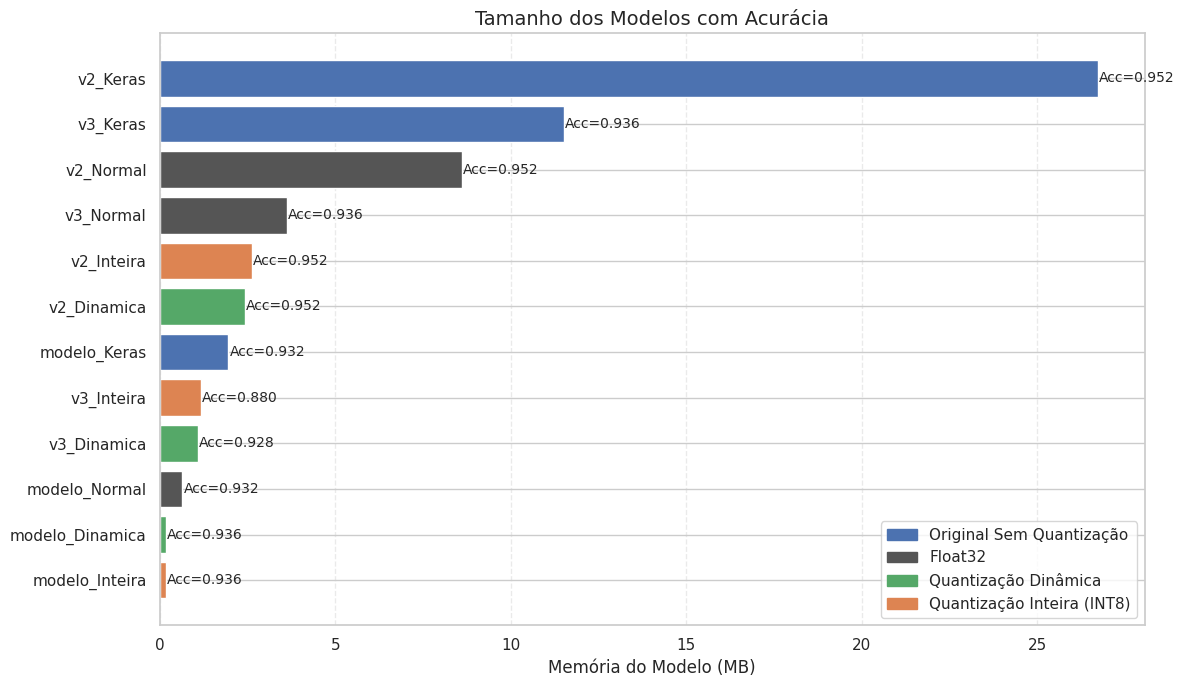

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_h = df_plot.sort_values('Tamanho (MB)', ascending=True)

cores_tipo = {
    'Keras': '#4c72b0',     # azul
    'Normal': '#555555',   # cinza
    'Dinamica': '#55a868', # verde
    'Inteira': '#dd8452'   # laranja
}

cores = df_h['Tipo'].map(cores_tipo)

plt.figure(figsize=(12, 7))

barras = plt.barh(df_h['Modelo'], df_h['Tamanho (MB)'], color=cores)

plt.xlabel('Memória do Modelo (MB)')
plt.title('Tamanho dos Modelos com Acurácia', fontsize=14)


# anotar acurácia
for i, bar in enumerate(barras):
    acc = df_h['Acurácia'].iloc[i]
    tamanho = df_h['Tamanho (MB)'].iloc[i]

    plt.text(
        tamanho + 0.03,
        bar.get_y() + bar.get_height()/2,
        f'Acc={acc:.3f}',
        va='center',
        fontsize=10
    )

# -------- legenda neutra --------
legend_items = [
    mpatches.Patch(color='#4c72b0', label='Original Sem Quantização'),
    mpatches.Patch(color='#555555', label='Float32'),
    mpatches.Patch(color='#55a868', label='Quantização Dinâmica'),
    mpatches.Patch(color='#dd8452', label='Quantização Inteira (INT8)')
]

plt.legend(handles=legend_items, loc='lower right')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### **Grafico Modelo X Arena Size**

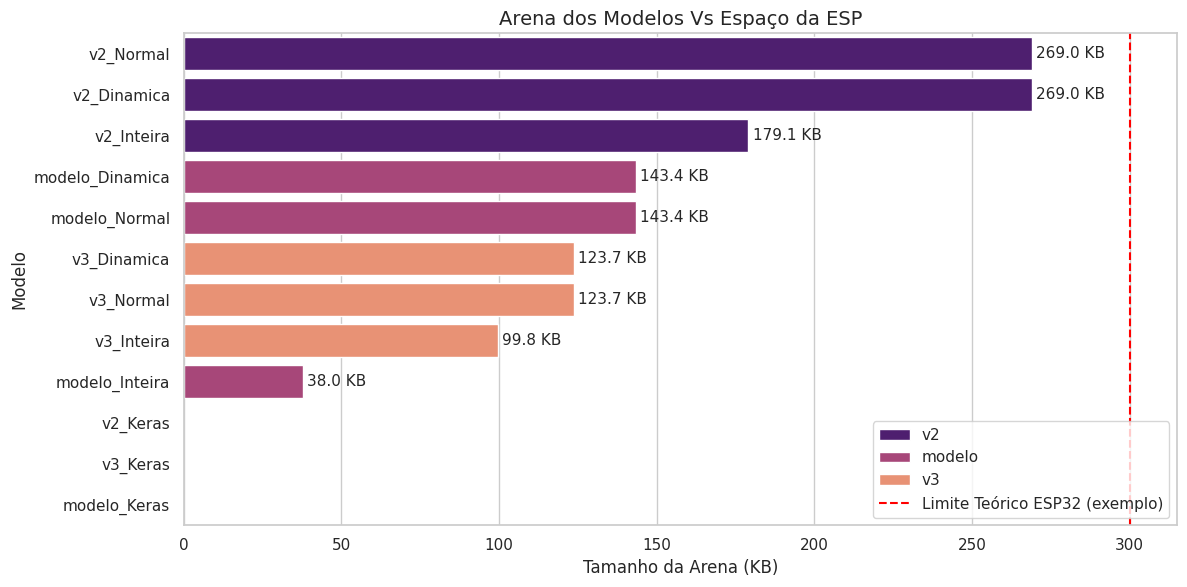

In [ ]:
plt.figure(figsize=(12, 6))

df_sorted = df_plot.sort_values('Arena (KB)', ascending=False)

ax = sns.barplot(
    data=df_sorted,
    x='Arena (KB)',
    y='Modelo',
    hue='Arquitetura',
    dodge=False,
    palette='magma'
)

plt.title('Arena dos Modelos Vs Espaço da ESP', fontsize=14)
plt.xlabel('Tamanho da Arena (KB)')

plt.axvline(
    x=300,
    color='red',
    linestyle='--',
    label='Limite Teórico ESP32 (exemplo)'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f KB', padding=3)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# **Site para verificar a estrutura da rede**
https://netron.app/